In [1]:
from google.colab import files
uploaded = files.upload()

Saving northstar_dataset.zip to northstar_dataset.zip


In [2]:
import zipfile
import os

zip_path = "northstar_dataset.zip"
extract_path = "/content/northstar_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")
print(os.listdir(extract_path))

Dataset extracted successfully
['northstar_dataset']


In [3]:
import pandas as pd
import numpy as np

path = "/content/northstar_data/northstar_dataset"

orders = pd.read_csv(path + "/orders.csv")
deliveries = pd.read_csv(path + "/deliveries.csv")
customers = pd.read_csv(path + "/customers.csv")
complaints = pd.read_csv(path + "/complaints.csv")
incidents = pd.read_csv(path + "/incidents.csv")
drivers = pd.read_csv(path + "/drivers.csv")
vehicles = pd.read_csv(path + "/vehicles.csv")
hubs = pd.read_csv(path + "/hubs.csv")
app_events = pd.read_csv(path + "/app_events.csv")

print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Customers:", customers.shape)
print("Complaints:", complaints.shape)
print("Incidents:", incidents.shape)
print("Drivers:", drivers.shape)
print("Vehicles:", vehicles.shape)
print("Hubs:", hubs.shape)
print("App events:", app_events.shape)

Orders: (1250, 11)
Deliveries: (950, 13)
Customers: (650, 9)
Complaints: (320, 10)
Incidents: (280, 7)
Drivers: (170, 8)
Vehicles: (120, 8)
Hubs: (8, 5)
App events: (640, 10)


In [4]:
datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "complaints": complaints,
    "incidents": incidents,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "app_events": app_events
}

for name, df in datasets.items():
    print("\n", name.upper())
    print(df.isnull().sum())


 ORDERS
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

 DELIVERIES
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

 CUSTOMERS
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
ap

In [5]:
zone_columns = {
    "orders": ["pickup_zone", "dropoff_zone"],
    "customers": ["home_zone"],
    "drivers": ["base_zone"],
    "vehicles": ["assigned_zone"],
    "hubs": ["zone"],
    "app_events": ["zone_context"]
}

for df_name, cols in zone_columns.items():
    df = datasets[df_name]
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.title()

print(orders[["pickup_zone", "dropoff_zone"]].head())
print(customers[["home_zone"]].head())

  pickup_zone dropoff_zone
0     Airport        South
1       North      Airport
2        West      Airport
3   Riverside        North
4   Riverside        South
   home_zone
0      North
1    Airport
2       East
3    Central
4  Riverside


In [6]:
# Count complaints per order
complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index()

# Count incidents per delivery
incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    avg_resolved_hours=("resolved_hours", "mean")
).reset_index()

# Merge orders with deliveries
master = orders.merge(deliveries, on="order_id", how="left")

# Add customer data
master = master.merge(customers, on="customer_id", how="left")

# Add hub data
master = master.merge(hubs, on="hub_id", how="left")

# Add complaints
master = master.merge(complaint_summary, on="order_id", how="left")

# Add incidents
master = master.merge(incident_summary, on="delivery_id", how="left")

# Fill missing complaint/incident counts with 0
master["complaint_count"] = master["complaint_count"].fillna(0)
master["incident_count"] = master["incident_count"].fillna(0)
master["total_compensation"] = master["total_compensation"].fillna(0)

print(master.shape)
master.head()

(1250, 40)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,account_status,hub_name,zone,hub_type,capacity_score,complaint_count,total_compensation,avg_resolution_days,incident_count,avg_resolved_hours
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,Active,North Exchange,North,Dispatch,82.0,0.0,0.00,NaN,0.0,NaN
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,Dormant,NaN,NaN,NaN,NaN,0.0,0.00,NaN,0.0,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,Active,South Link,South,Dispatch,78.0,1.0,8.66,2.0,0.0,NaN
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,Active,South Link,South,Dispatch,78.0,0.0,0.00,NaN,0.0,NaN
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,Active,East Dock,East,Warehouse,74.0,1.0,54.41,8.0,0.0,NaN


In [7]:
master["is_failed"] = master["delivery_status"].apply(lambda x: 1 if x == "Failed" else 0)
master["has_complaint"] = master["complaint_count"].apply(lambda x: 1 if x > 0 else 0)
master["has_incident"] = master["incident_count"].apply(lambda x: 1 if x > 0 else 0)

master["cost_per_km"] = master["fuel_or_charge_cost"] / master["route_distance_km"]

master["high_risk_delivery"] = master.apply(
    lambda row: 1 if row["is_failed"] == 1 or row["has_complaint"] == 1 or row["has_incident"] == 1 else 0,
    axis=1
)

master[["order_id", "delivery_status", "is_failed", "has_complaint", "has_incident", "cost_per_km", "high_risk_delivery"]].head()

,order_id,delivery_status,is_failed,has_complaint,has_incident,cost_per_km,high_risk_delivery
0,O00001,OnTime,0,0,0,0.593621,0
1,O00002,NaN,0,0,0,NaN,0
2,O00003,Delayed,0,1,0,1.009202,1
3,O00004,OnTime,0,0,0,1.296905,0
4,O00005,OnTime,0,1,0,0.845097,1


In [8]:
total_orders = master["order_id"].nunique()
failed_rate = master["is_failed"].mean() * 100
complaint_rate = master["has_complaint"].mean() * 100
incident_rate = master["has_incident"].mean() * 100
avg_rating = master["customer_rating_post_delivery"].mean()
avg_cost = master["fuel_or_charge_cost"].mean()
total_compensation = master["total_compensation"].sum()

kpi_table = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Failed Delivery Rate (%)",
        "Complaint Rate (%)",
        "Incident Rate (%)",
        "Average Customer Rating",
        "Average Fuel/Charge Cost",
        "Total Compensation"
    ],
    "Value": [
        total_orders,
        round(failed_rate, 2),
        round(complaint_rate, 2),
        round(incident_rate, 2),
        round(avg_rating, 2),
        round(avg_cost, 2),
        round(total_compensation, 2)
    ]
})

kpi_table

,KPI,Value
0,Total Orders,1250.00
1,Failed Delivery Rate (%),10.56
2,Complaint Rate (%),22.80
3,Incident Rate (%),19.84
4,Average Customer Rating,3.86
5,Average Fuel/Charge Cost,12.84
6,Total Compensation,6158.19


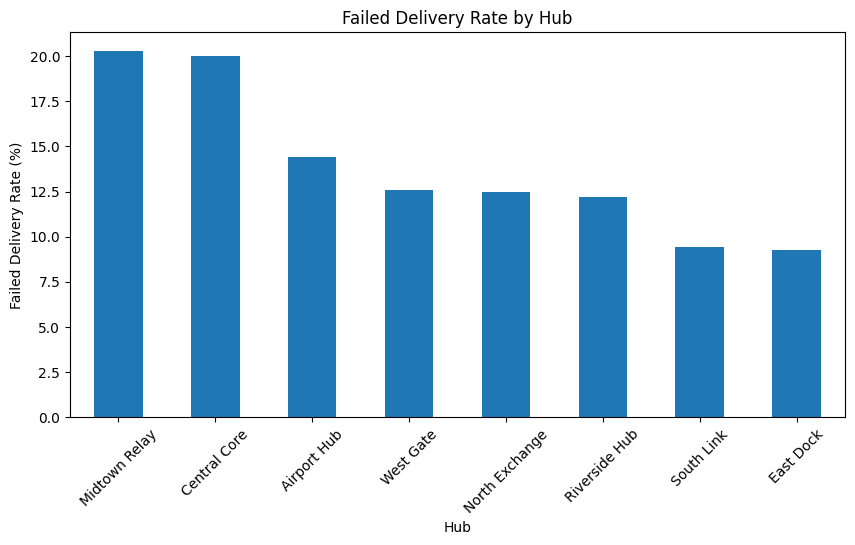

In [9]:
import matplotlib.pyplot as plt

failed_by_hub = master.groupby("hub_name")["is_failed"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,5))
failed_by_hub.plot(kind="bar")
plt.title("Failed Delivery Rate by Hub")
plt.xlabel("Hub")
plt.ylabel("Failed Delivery Rate (%)")
plt.xticks(rotation=45)
plt.show()

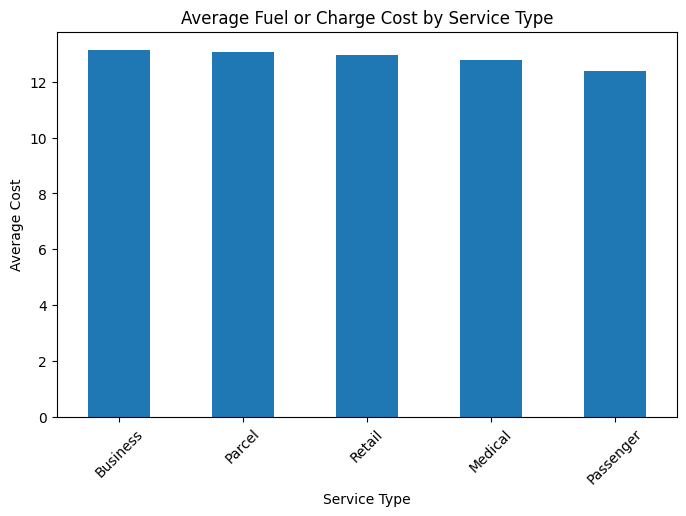

In [10]:
cost_by_service = master.groupby("service_type")["fuel_or_charge_cost"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
cost_by_service.plot(kind="bar")
plt.title("Average Fuel or Charge Cost by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Cost")
plt.xticks(rotation=45)
plt.show()

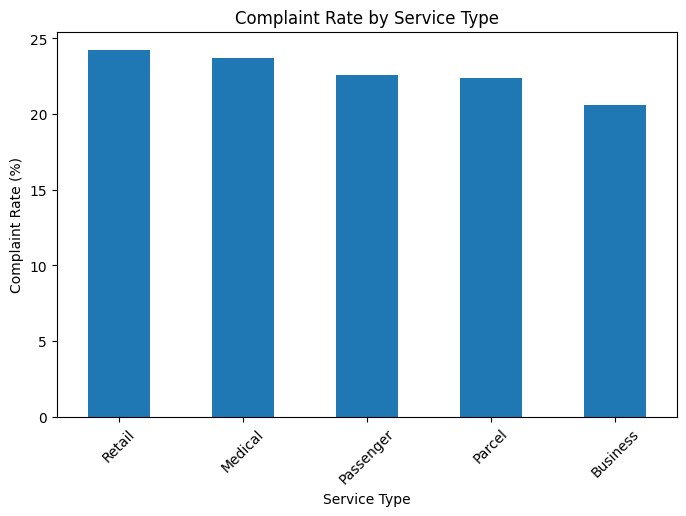

In [12]:
complaints_by_service = master.groupby("service_type")["has_complaint"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
complaints_by_service.plot(kind="bar")
plt.title("Complaint Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Complaint Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [13]:
master.to_csv("northstar_master_dataset.csv", index=False)
print("Master dataset saved successfully")

Master dataset saved successfully


In [14]:
from google.colab import files
files.download("northstar_master_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>